# Regression in Pytorch


In [1]:
import torch
import matplotlib.pyplot as plt

In [186]:
x  = torch.tensor([0,1,2,3,4,5,6,7.]) # E.g.: Dosage of drug for treating Alzheimer's disease
x

tensor([0., 1., 2., 3., 4., 5., 6., 7.])

In [187]:
y - -0.5*0 + 2 + torch.normal(mean=torch.zeros(8), std=0.2)

tensor([[20.6422, 21.1084, 20.8933, 20.8130, 20.9816, 20.4283, 20.9026, 20.7798],
        [13.8016, 14.2678, 14.0526, 13.9723, 14.1409, 13.5877, 14.0619, 13.9391],
        [ 6.9381,  7.4043,  7.1892,  7.1088,  7.2775,  6.7242,  7.1984,  7.0757],
        [25.1753, 25.6415, 25.4264, 25.3460, 25.5147, 24.9614, 25.4357, 25.3129],
        [46.5574, 47.0236, 46.8085, 46.7281, 46.8967, 46.3435, 46.8177, 46.6949],
        [ 1.6219,  2.0882,  1.8730,  1.7927,  1.9613,  1.4080,  1.8823,  1.7595],
        [81.5781, 82.0443, 81.8292, 81.7488, 81.9175, 81.3642, 81.8385, 81.7157],
        [16.2946, 16.7608, 16.5457, 16.4653, 16.6340, 16.0807, 16.5550, 16.4322],
        [11.7739, 12.2401, 12.0250, 11.9446, 12.1133, 11.5600, 12.0343, 11.9115],
        [24.8618, 25.3280, 25.1129, 25.0325, 25.2012, 24.6479, 25.1222, 24.9994],
        [ 3.5696,  4.0358,  3.8207,  3.7403,  3.9090,  3.3557,  3.8300,  3.7072],
        [10.0772, 10.5434, 10.3283, 10.2480, 10.4166,  9.8633, 10.3376, 10.2148],
        [47.8643

"The y values were created using the equation of a line y = mx + b. This way, we know what the model parameters to be learned are, say, m = -0.5 and b = 2. Random, normally-distributed noise has been added to simulate sampling error."

For reproducibility of this demo, here's a fixed example of y values obtained by running the commented-out line above:

In [188]:
y = torch.tensor([1.86, 1.31, .62, .33, .09, -.67, -1.23, -1.37]) # E.g.: Patient's "forgetfulness score"
y

tensor([ 1.8600,  1.3100,  0.6200,  0.3300,  0.0900, -0.6700, -1.2300, -1.3700])

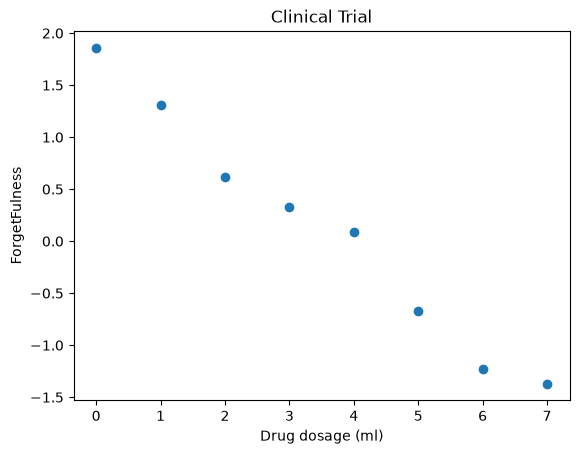

In [189]:
fig, ax = plt.subplots()
plt.title("Clinical Trial")
plt.xlabel("Drug dosage (ml)")
plt.ylabel("ForgetFulness")
plt.scatter(x,y)

Initialize the slope parameter **m** with a "random" value of 0.9...

**(N.B.:** In this simple demo, we could guess approximately-correct parameter values to start with. Or, we could use an algebraic (e.g, Moore-Penrose pseudoinverse) or statistical (e.g, ordinary-least-squares regression) to solve for the parameters quickly. This tiny machine learning demo with two parameters and eight data points scales, however, to millions of parameters and millions of data points. The other approaches -- guessing, algebra, statistics -- do not come close to scaling in this way.)

In [190]:
m = torch.tensor([0.9]).requires_grad_()
m

tensor([0.9000], requires_grad=True)

.and do the same for the y-intercept parameter b:

In [191]:
b = torch.tensor([0.1]).requires_grad_()
b

tensor([0.1000], requires_grad=True)

In [192]:
def regression_plot(x,y,m,b):
    fig, ax = plt.subplots()
    plt.scatter(x,y)
    x_min, x_max = ax.get_xlim()
    y_min = regression(x_min, m, b).detach().item()
    y_max = regression(x_max, m, b).detach().item()
    
    ax.set_xlim([x_min, x_max])
    _ = ax.plot([x_min, x_max], [y_min, y_max])

In [193]:
def regression(x,y,b):
    return x*y+b

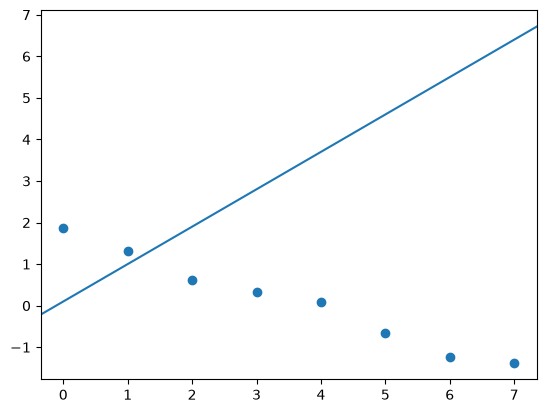

In [194]:
regression_plot(x, y, m, b)

# machine learning

**Step 2:** Compare ŷ with true *y* to calculate cost *C*

There is a PyTorch `MSELoss` method, but let's define it ourselves to see how it works. MSE cost is defined by:

$$C = \frac{1}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i)^2$$

In [195]:
x

tensor([0., 1., 2., 3., 4., 5., 6., 7.])

In [196]:
m

tensor([0.9000], requires_grad=True)

In [197]:
b

tensor([0.1000], requires_grad=True)

In [198]:
y

tensor([ 1.8600,  1.3100,  0.6200,  0.3300,  0.0900, -0.6700, -1.2300, -1.3700])

In [199]:
# Step 1 :Forward passz
yhat = regression(x,m,b)
yhat

tensor([0.1000, 1.0000, 1.9000, 2.8000, 3.7000, 4.6000, 5.5000, 6.4000],
       grad_fn=<AddBackward0>)

In [200]:
def mse(my_yhat, my_y):
    sigma = torch.sum((my_yhat - my_y) **2)
    return sigma/len(my_y)

In [201]:
c = mse(yhat, y)
c

tensor(19.6755, grad_fn=<DivBackward0>)

**Step 3:** Use autodiff to calculate gradient of *C* w.r.t. parameters

In [202]:
c.backward()

In [203]:
m.grad

tensor([36.3050])

In [ ]:
b.grad


# step 4:gradient descent

In [ ]:
optimizer = torch.optim.SGD([m,b], lr = 0.01)

In [ ]:
optimizer.step()

confirm parameters have been adjusted sensibly:

In [ ]:
m

In [ ]:
b

In [ ]:
regression_plot(x,y,m,b)

we can use steps 1 and 2 to confirm cost has decreased:

In [ ]:
c = mse(regression(x,m,b),y)
c


In [ ]:
epochs = 1000
for epoch in range(epochs):
    
    optimizer.zero_grad() # Reset gradients to zero; else they accumulate
    
    yhat = regression(x, m, b) # Step 1
    C = mse(yhat, y) # Step 2
    
    C.backward() # Step 3
    optimizer.step() # Step 4
    
    print('Epoch {}, cost {}, m grad {}, b grad {}'.format(epoch, '%.3g' % C.item(), '%.3g' % m.grad.item(), '%.3g' % b.grad.item()))

In [ ]:
regression_plot(x,y,m,b)

In [ ]:
m.item()

In [ ]:
b.item()

N.B.: The model doesn't perfectly approximate the slope (-0.5) and y-intercept (2.0) used to simulate the outcomes y at the top of this notebook. This reflects the imperfectness of the sample of eight data points due to adding random noise during the simulation step. In the real world, the best solution would be to sample additional data points: The more data we sample, the more accurate our estimates of the true underlying parameters will be.

1. Use PyTorch (or TensorFlow, if you like) to find the slope of 
   y = x^2 + 2x + 2 where x = 2.

2. Use the Regression in PyTorch notebook to simulate a new 
   linear relationship between y and x, and then fit the parameters 
   m and b.

3. Read about how differential programming, wherein computer 
   programs can be differentiated, could be common soon 
   (perhaps thanks to quantum ML; see pennylane.ai).

In [2]:
# question 1 solution
x = torch.tensor(2.0, requires_grad=True)
x



tensor(2., requires_grad=True)

In [3]:
def regression_eqn(x):
    return (x**2 + 2 * x + 2)

In [4]:
y = regression_eqn(x)
y.backward()

In [5]:
print("The slope (dy/dx) at x=2 is:", x.grad)


The slope (dy/dx) at x=2 is: tensor(6.)


In [6]:
# Question 2 Solution

In [7]:
x = torch.rand(100, 1) * 15


In [8]:
noise = torch.normal(mean=0.0, std=5.0, size=(100, 1))
y = 0.5 * (x**2) - 3 * x + 10 + noise

In [9]:
y

tensor([[ 5.3281],
        [49.7822],
        [38.5257],
        [49.7818],
        [80.5088],
        [59.6989],
        [29.7461],
        [ 2.6778],
        [25.5972],
        [ 2.5736],
        [ 1.0212],
        [ 9.3877],
        [57.0888],
        [76.0298],
        [55.4964],
        [13.5250],
        [21.1394],
        [23.2941],
        [11.8159],
        [41.7219],
        [ 7.9645],
        [ 8.7711],
        [ 2.7116],
        [ 8.3761],
        [52.3791],
        [12.0426],
        [17.6666],
        [16.3201],
        [ 0.1848],
        [26.6932],
        [59.1233],
        [10.7923],
        [ 8.9079],
        [33.5825],
        [ 3.2099],
        [67.5456],
        [26.0187],
        [ 1.3833],
        [ 6.7535],
        [41.4250],
        [ 8.1354],
        [13.6732],
        [22.7643],
        [22.6405],
        [ 7.6082],
        [18.2094],
        [14.7375],
        [42.5909],
        [11.3367],
        [ 6.2986],
        [32.5659],
        [25.2337],
        [16.

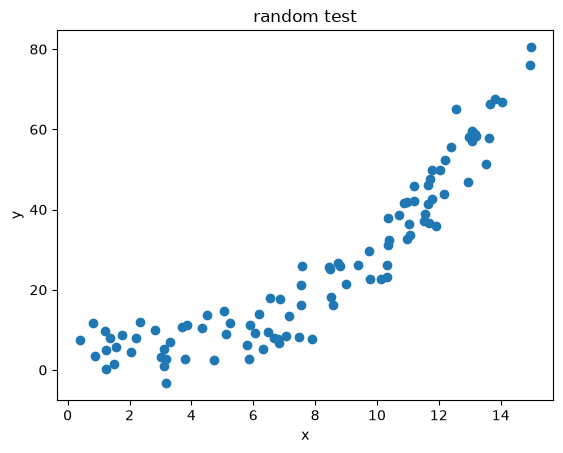

In [10]:
fig, ax = plt.subplots()
plt.title("random test")
plt.xlabel("x")
plt.ylabel("y")
_ = ax.scatter(x, y)

In [11]:
# 3. Initialize m and b completely wrong
m = torch.tensor([5.0], requires_grad=True)
b = torch.tensor([-60.0], requires_grad=True)

In [12]:
def regression_plot(my_x, my_y, my_m, my_b):
    
    fig, ax = plt.subplots()

    ax.scatter(my_x, my_y)
    
    x_min, x_max = ax.get_xlim()
    y_min = regression(x_min, my_m, my_b).detach().item()
    y_max = regression(x_max, my_m, my_b).detach().item()
    
    ax.set_xlim([x_min, x_max])
    _ = ax.plot([x_min, x_max], [y_min, y_max])

In [14]:
def regression(my_x, my_m, my_b):
    return my_m*my_x + my_b

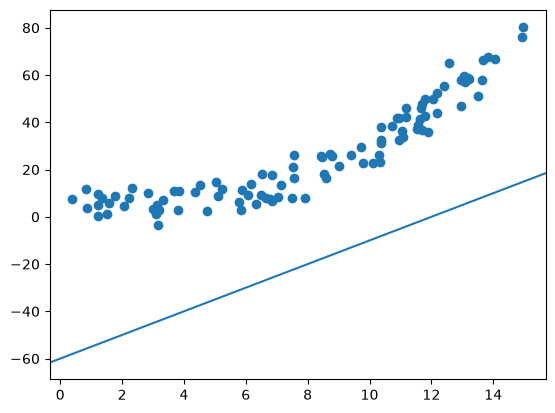

In [15]:
regression_plot(x, y, m, b)

In [16]:
yhat = regression(x, m, b)
yhat

tensor([[-28.3435],
        [  0.2195],
        [ -6.4324],
        [ -1.0837],
        [ 14.8373],
        [  5.3166],
        [-11.3371],
        [-41.0305],
        [-17.8245],
        [-36.3236],
        [-44.5029],
        [-27.5380],
        [  5.3583],
        [ 14.6617],
        [  1.9644],
        [-24.2812],
        [-22.3571],
        [ -8.3325],
        [-55.8862],
        [ -5.5998],
        [-53.1942],
        [-51.1916],
        [-30.7232],
        [-24.7849],
        [  0.9275],
        [-48.3636],
        [-25.7306],
        [-22.2681],
        [-53.8537],
        [-16.3233],
        [  5.3468],
        [-41.5520],
        [-34.4459],
        [ -4.5816],
        [-44.9671],
        [  9.0765],
        [-22.1945],
        [-52.4446],
        [-25.8124],
        [ -1.8267],
        [-22.5592],
        [-37.4087],
        [ -9.3828],
        [-11.0546],
        [-26.0757],
        [-17.3502],
        [-34.7515],
        [ -1.0368],
        [-30.6037],
        [-31.0301],


In [17]:
def mse(my_yhat, my_y): 
    sigma = torch.sum((my_yhat - my_y)**2)
    return sigma/len(my_y)

In [18]:
C = mse(yhat, y)
C

tensor(2218.4429, grad_fn=<DivBackward0>)

In [19]:
C.backward()

In [20]:
m.grad

tensor([-731.5070])

In [21]:
b.grad

tensor([-92.4448])

In [22]:
optimizer = torch.optim.SGD([m, b], lr=0.01)

In [23]:
optimizer.step()

In [24]:
m

tensor([12.3151], requires_grad=True)

In [25]:
b

tensor([-59.0756], requires_grad=True)

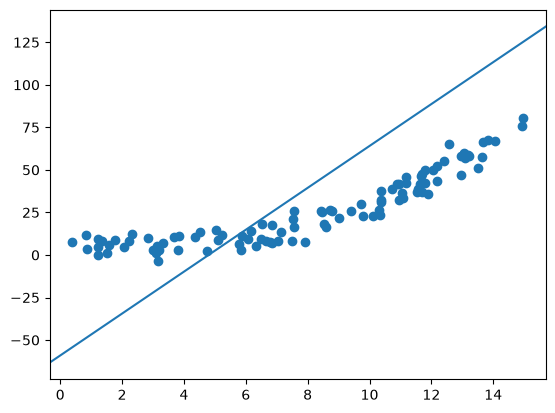

In [26]:
regression_plot(x, y, m, b)

In [27]:
C = mse(regression(x, m, b), y)
C

tensor(1246.0360, grad_fn=<DivBackward0>)

In [28]:
epochs = 10000
for epoch in range(epochs):
    
    optimizer.zero_grad() # Reset gradients to zero; else they accumulate
    
    yhat = regression(x, m, b) # Step 1
    C = mse(yhat, y) # Step 2
    
    C.backward() # Step 3
    optimizer.step() # Step 4
    
    print('Epoch {}, cost {}, m grad {}, b grad {}'.format(epoch, '%.3g' % C.item(), '%.3g' % m.grad.item(), '%.3g' % b.grad.item()))

Epoch 0, cost 1.25e+03, m grad 474, b grad 27.2
Epoch 1, cost 841, m grad -302, b grad -49.7
Epoch 2, cost 671, m grad 197, b grad -0.0789
Epoch 3, cost 599, m grad -124, b grad -31.9
Epoch 4, cost 567, m grad 82.8, b grad -11.3
Epoch 5, cost 551, m grad -50.1, b grad -24.4
Epoch 6, cost 542, m grad 35.4, b grad -15.8
Epoch 7, cost 537, m grad -19.7, b grad -21.2
Epoch 8, cost 532, m grad 15.8, b grad -17.6
Epoch 9, cost 528, m grad -7.05, b grad -19.8
Epoch 10, cost 524, m grad 7.61, b grad -18.3
Epoch 11, cost 521, m grad -1.83, b grad -19.1
Epoch 12, cost 517, m grad 4.23, b grad -18.5
Epoch 13, cost 514, m grad 0.317, b grad -18.8
Epoch 14, cost 510, m grad 2.82, b grad -18.4
Epoch 15, cost 507, m grad 1.2, b grad -18.5
Epoch 16, cost 503, m grad 2.23, b grad -18.3
Epoch 17, cost 500, m grad 1.55, b grad -18.3
Epoch 18, cost 497, m grad 1.98, b grad -18.2
Epoch 19, cost 493, m grad 1.69, b grad -18.2
Epoch 20, cost 490, m grad 1.86, b grad -18.1
Epoch 21, cost 487, m grad 1.74, b g

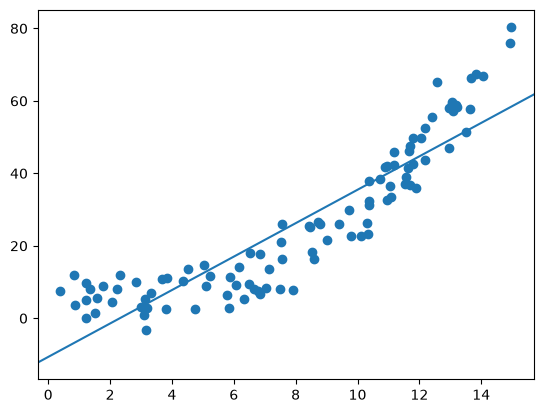

In [29]:
regression_plot(x, y, m, b)